# Experiment Record-color analysis of raw data 

## Environment

In [2]:
pip install opencv-python

Note: you may need to restart the kernel to use updated packages.


In [3]:
pip install matplotlib

Note: you may need to restart the kernel to use updated packages.


In [4]:
import sys
sys.path.append('../src/data') # add self-defined script path
import image_utils # self-defined library
from color_engine import ColorHistogramEngine, ColorAnalysisFacade # self-defined library
import color_utils
import cv2
import numpy as np
import os
import matplotlib.pyplot as plt

## rgb distribution vs hue distribution

In [6]:
img_path = '../raw_data/2D_Fragments/2D_Images/assembled_objects/RPobj_g2_o0002/RPf_00015_intact_mesh.png'

In [7]:
# read the image

img_raw = cv2.imread(img_path, cv2.IMREAD_UNCHANGED)
img_raw_no_alpha = cv2.imread(img_path)

"""
print(img_raw)
print(img_raw_no_alpha)
"""

'\nprint(img_raw)\nprint(img_raw_no_alpha)\n'

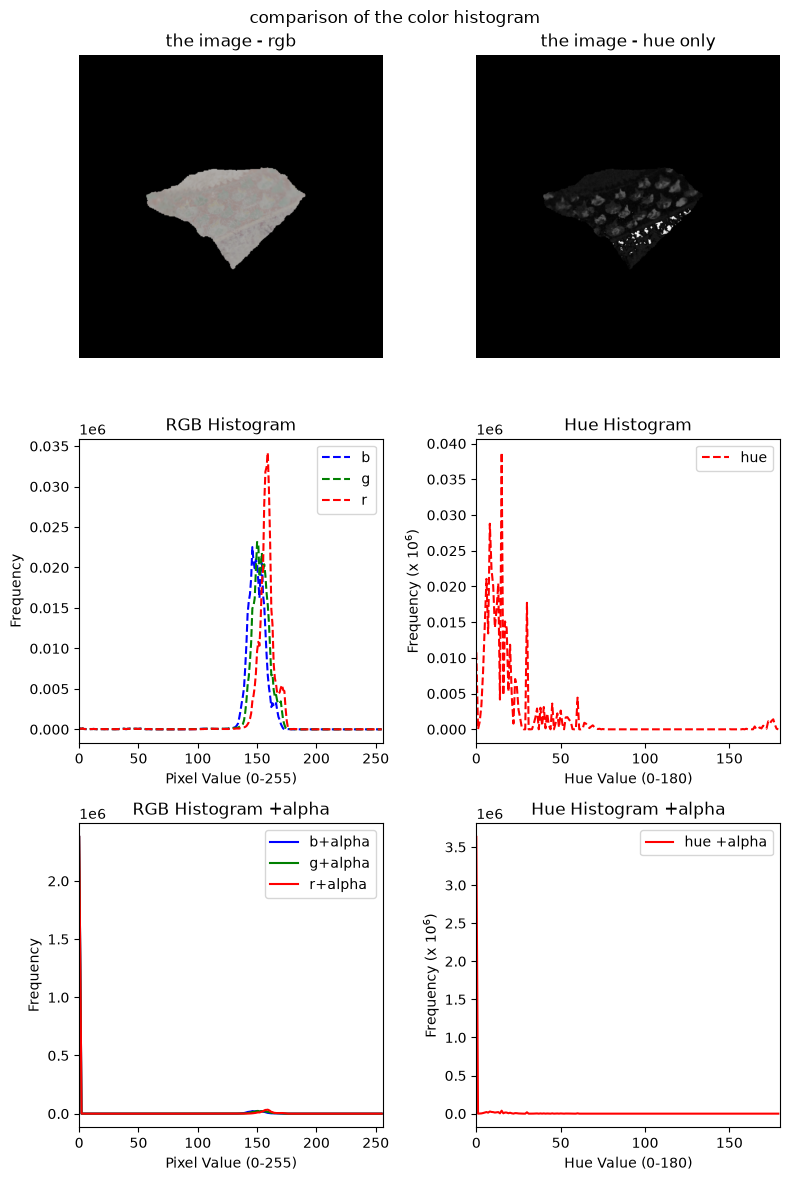

In [8]:
import cv2
import matplotlib.pyplot as plt

# check alpha channel
"""
alpha = img_raw[:, :, 3]
img_raw_test = img_raw[:, :, :3]
alpha_filter = np.where(alpha > 0, 255, 0).astype(np.uint8)
hist_test = cv2.calcHist([img_raw_test], [0], alpha_filter, [256], [0, 256])
hist_test_alpha = cv2.calcHist([img_raw_test], [0], None, [256], [0, 256])
print(np.unique(alpha_filter))
print(hist_test)
print(hist_test_alpha)
"""

# calculate the color histogram of the rgb
rgb_engine = ColorHistogramEngine('rgb')
rgb_hist = rgb_engine.calculate_hist(img_path)

# calculate the color histogram of the hue
hue_engine =  ColorHistogramEngine('hue')
hue_hist = hue_engine.calculate_hist(img_raw)

# calculate the color histogram of the rgb including alpha
rgb_engine_alpha = ColorHistogramEngine('rgb')
rgb_hist_alpha = rgb_engine_alpha.calculate_hist(img_raw_no_alpha)

# calculate the color histogram of the hue including alpha
hue_engine_alpha =  ColorHistogramEngine('hue', False)
hue_hist_alpha = hue_engine_alpha.calculate_hist(img_path)

# show the color distribution and the raw image
fig, axes = plt.subplots(3, 2, figsize=(8, 12))

# show the rgb distribution
colors = ('b', 'g', 'r')

for i, color in enumerate(colors):
    hist = rgb_hist[i]
    axes[1, 0].plot(hist, color = color, linestyle = "--", label = colors[i])
    hist_alpha = rgb_hist_alpha[i]
    axes[2, 0].plot(hist_alpha, color = color, label = f"{colors[i]}+alpha")

axes[1, 0].set_title('RGB Histogram')
axes[1, 0].set_xlabel('Pixel Value (0-255)')
axes[1, 0].set_ylabel('Frequency')
axes[1, 0].set_xlim([0, 256])
axes[1, 0].ticklabel_format(style = 'sci', axis = 'y', scilimits = (6,6))
axes[1, 0].legend()

axes[2, 0].set_title('RGB Histogram +alpha')
axes[2, 0].set_xlabel('Pixel Value (0-255)')
axes[2, 0].set_ylabel('Frequency')
axes[2, 0].set_xlim([0, 256])
axes[2, 0].ticklabel_format(style = 'sci', axis = 'y', scilimits = (6,6))
axes[2, 0].legend()

# show the hue distribution
axes[1, 1].plot(hue_hist, color = color[0], linestyle='--', label = 'hue')
axes[2, 1].plot(hue_hist_alpha, color = color[0], label = 'hue +alpha')

axes[1, 1].set_title('Hue Histogram')
axes[1, 1].set_xlabel('Hue Value (0-180)')
axes[1, 1].set_ylabel('Frequency (x $10^6$)')
axes[1, 1].set_xlim([0, 180])
axes[1, 1].ticklabel_format(style = 'sci', axis = 'y', scilimits = (6,6))
axes[1, 1].legend()

axes[2, 1].set_title('Hue Histogram +alpha')
axes[2, 1].set_xlabel('Hue Value (0-180)')
axes[2, 1].set_ylabel('Frequency (x $10^6$)')
axes[2, 1].set_xlim([0, 180])
axes[2, 1].ticklabel_format(style = 'sci', axis = 'y', scilimits = (6,6))
axes[2, 1].legend()

# show the image
img_rgb = cv2.cvtColor(img_raw, cv2.COLOR_BGR2RGB)
img_hsv = cv2.cvtColor(img_raw, cv2.COLOR_BGR2HSV)
hue_channel = img_hsv[:, :, 0]

axes[0, 0].imshow(img_rgb)
axes[0, 0].axis('off')
axes[0, 0].set_title("the image - rgb") 

axes[0, 1].imshow(hue_channel, cmap = 'gray')
axes[0, 1].axis('off')
axes[0, 1].set_title("the image - hue only") 

fig.suptitle("comparison of the color histogram")
plt.tight_layout()
plt.show()

## linear mean vs ring mean for multiple images

In [10]:
img_dir = "../raw_data/2D_Fragments/2D_Images/assembled_objects/RPobj_g2_o0002"
img_paths = image_utils.get_image_paths(img_dir)

In [11]:
hue_eng =  ColorHistogramEngine('hue')
hue_linear_means = hue_eng.calculate_linear_means(img_paths)
hue_linear_mean_total = hue_eng.calculate_linear_mean_total(img_paths)
print("hue_linear_means:", hue_linear_means)
print("hue_linear_mean_total:", hue_linear_mean_total)

hue_linear_means: [np.float64(14.315011239285626), np.float64(19.62643775776137), np.float64(13.83035656779346), np.float64(19.07257282388142), np.float64(24.189212057112638), np.float64(17.270767502282144), np.float64(23.637714513403225)]
hue_linear_mean_total: 19.550783000066946


In [12]:
hue_analyzer = ColorAnalysisFacade(img_path,'hue')
hue_ring_mean = hue_analyzer.get_hue_circular_mean()
print("hue_ring_mean:", hue_ring_mean)

hue_ring_mean: 15.352920803497165


In [13]:
hue_analyzer_imgs = ColorAnalysisFacade(img_paths,'hue')
imgs_ring_means = hue_analyzer_imgs.get_hue_circular_means()
imgs_ring_mean_total = hue_analyzer_imgs.get_hue_circular_mean_total()
imgs_linear_means = hue_analyzer_imgs.get_hue_linear_means()
imgs_linear_mean_total = hue_analyzer_imgs.get_hue_linear_mean_total()
imgs_ring_means_alpha = hue_analyzer_imgs.get_hue_circular_means_alpha()
imgs_ring_mean_total_alpha = hue_analyzer_imgs.get_hue_circular_mean_total_alpha()
imgs_linear_means_alpha = hue_analyzer_imgs.get_hue_linear_means_alpha()
imgs_linear_mean_total_alpha = hue_analyzer_imgs.get_hue_linear_mean_total_alpha()
print("ring_mean:", imgs_ring_means)
print("total_ring_mean:", imgs_ring_mean_total)
print("linear_mean:", imgs_linear_means)
print("total_linear_mean:", imgs_linear_mean_total)
print("ring_mean_alpha:", imgs_ring_means_alpha)
print("total_ring_mean_alpha:", imgs_ring_mean_total_alpha)
print("linear_mean_alpha:", imgs_linear_means_alpha)
print("total_linear_mean_alpha:", imgs_linear_mean_total_alpha)


ring_mean: [13.998518730750726, 15.352920803497165, 13.71160645424536, 18.467708236664304, 14.142152319079305, 16.00498540609208, 13.61428925988005]
total_ring_mean: 14.749655988406458
linear_mean: [np.float64(14.315011239285626), np.float64(19.62643775776137), np.float64(13.83035656779346), np.float64(19.07257282388142), np.float64(24.189212057112638), np.float64(17.270767502282144), np.float64(23.637714513403225)]
total_linear_mean: 19.550783000066946
ring_mean_alpha: [0.6774852021546052, 1.2692513943944235, 0.6563117247516687, 0.6172171627466633, 0.8704555199788835, 0.2636318427570062, 0.9048372375708759]
total_ring_mean_alpha: 0.7498917711851555
linear_mean_alpha: [np.float64(0.726395), np.float64(1.8513835), np.float64(0.699948), np.float64(0.69485375), np.float64(1.60296175), np.float64(0.309112), np.float64(1.722861)]
total_linear_mean_alpha: 1.086787857142857


In [14]:
def plot_hue_comparison(folder, max_images = 30):
    
    paths = image_utils.get_image_paths(folder)[:max_images]
    if not paths:
        print("no images")
        return None, None, None
        
    imgs_arr = []
    img_names = []
    for p in paths:
        img_raw = cv2.imread(str(p), cv2.IMREAD_UNCHANGED)
        name = os.path.basename(p)
        imgs_arr.append(img_raw)
        img_names.append(name)
    
    hue_analyzer =  ColorAnalysisFacade(imgs_arr, strategy = 'hue')
    
    # calculate hists
    hue_hists = hue_analyzer.get_hists()
    hue_hists_total = hue_analyzer.get_hists_total()

    # calculate avg
    avg_hues_liner_compress = hue_analyzer.get_hue_linear_means()
    print("liner_compress:", avg_hues_liner_compress)

    avg_hues_liner = hue_analyzer.get_hue_linear_means_alpha()
    print("liner", avg_hues_liner)
    
    avg_hues_ring_compress = hue_analyzer.get_hue_circular_means()
    print("ring_compress", avg_hues_ring_compress)

    avg_hues_ring = hue_analyzer.get_hue_circular_means_alpha()
    print("ring", avg_hues_ring)

    avg_hues_ring_total = hue_analyzer.get_hue_circular_mean_total()
    print("ring_total:", avg_hues_ring_total)
        

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
    n = len(img_names)

    # show total hue histogram of all images
    x = np.arange(180)
    hue_color = plt.cm.hsv(avg_hues_ring_total / 180)
    ax1.plot(x, hue_hists_total, color = hue_color, alpha = 0.5, linewidth = 1.0, label = "total")

    # show hue histogram of each image
    for i in range(n):
        hue_color = plt.cm.hsv(avg_hues_ring_compress[i] / 180)
        ax1.plot(x, hue_hists[i], color = hue_color, alpha = 0.5, linewidth = 1.0 + 0.2*i, label = img_names[i])
    gradient = np.linspace(0, 1, 180).reshape(1, -1)
    ax1.imshow(gradient, extent=[0, 180, 0, ax1.get_ylim()[1]*0.95],
              aspect = 'auto', cmap = 'hsv', alpha = 0.15, zorder = 0)
    ax1.set_xlim([0, 180])
    ax1.set_xlabel('Hue value(0=red, 60=yellow, 120=green, 180=blue-purple)', fontsize = 8)
    ax1.set_ylabel('frequency', fontsize = 8)
    ax1.set_title(f'hub distribution from {n}images', fontsize = 12)
    ax1.legend(ncol = 2)
    ax1.grid(True, alpha = 0.3)

    # show avg hue of each image
    x_pos = np.arange(n)
    bar_width = 0.4

    
    colors_line_compress = [plt.cm.hsv(avg / 180) for avg in avg_hues_liner_compress]
    bars_line_compress = ax2.bar(x_pos + bar_width - 0.1, avg_hues_liner_compress, color = colors_line_compress, 
                                 width = bar_width/2, label = 'linear_compress',
                                 linestyle = '--', edgecolor = 'blue')

    colors_ring_compress = [plt.cm.hsv(avg / 180) for avg in avg_hues_ring_compress]
    bars_ring_compress = ax2.bar(x_pos + bar_width/2 - 0.1, avg_hues_ring_compress, color = colors_ring_compress, 
                                 width = bar_width/2, label = 'ring_compress',
                                 linestyle = '--', edgecolor = 'green')

    colors_line = [plt.cm.hsv(avg / 180) for avg in avg_hues_liner]
    bars_line = ax2.bar(x_pos - bar_width/2 + 0.1, avg_hues_liner, color = colors_line, 
                        width = bar_width/2, label = 'linear', edgecolor = 'blue')

    colors_ring = [plt.cm.hsv(avg / 180) for avg in avg_hues_ring]
    bars_ring = ax2.bar(x_pos - bar_width + 0.1, avg_hues_ring, color = colors_ring, 
                        width = bar_width/2, label = 'ring', edgecolor = 'green')
    
    
    ax2.axhline(y = 90, color = 'black', linestyle='--', linewidth = 1, label = 'hue=(90)')
    
    if n > 10:
        labels = [img_names[i] if i % max(1, n // 8) == 0 else '' for i in range(n)]
    else:
        labels = img_names
    ax2.set_xticks(x_pos)
    ax2.set_xticklabels(labels, rotation = 45, ha = 'right', fontsize = 6)
    ax2.set_ylabel('the mean value of Hue', fontsize = 10)
    ax2.set_ylim([0, 200])
    ax2.set_title('the comparison of the images on the mean Hue', fontsize = 12)
    ax2.legend(ncol = 3)
    ax2.grid(axis = 'y', linestyle = '--', alpha = 0.3)

    plt.tight_layout()
    plt.show()

liner_compress: [np.float64(14.315011239285626), np.float64(19.62643775776137), np.float64(13.83035656779346), np.float64(19.07257282388142), np.float64(24.189212057112638), np.float64(17.270767502282144), np.float64(23.637714513403225)]
liner [np.float64(0.726395), np.float64(1.8513835), np.float64(0.699948), np.float64(0.69485375), np.float64(1.60296175), np.float64(0.309112), np.float64(1.722861)]
ring_compress [13.998518730750726, 15.352920803497165, 13.71160645424536, 18.467708236664304, 14.142152319079305, 16.00498540609208, 13.61428925988005]
ring [0.6774852021546052, 1.2692513943944235, 0.6563117247516687, 0.6172171627466633, 0.8704555199788835, 0.2636318427570062, 0.9048372375708759]
ring_total: 14.749655988406458


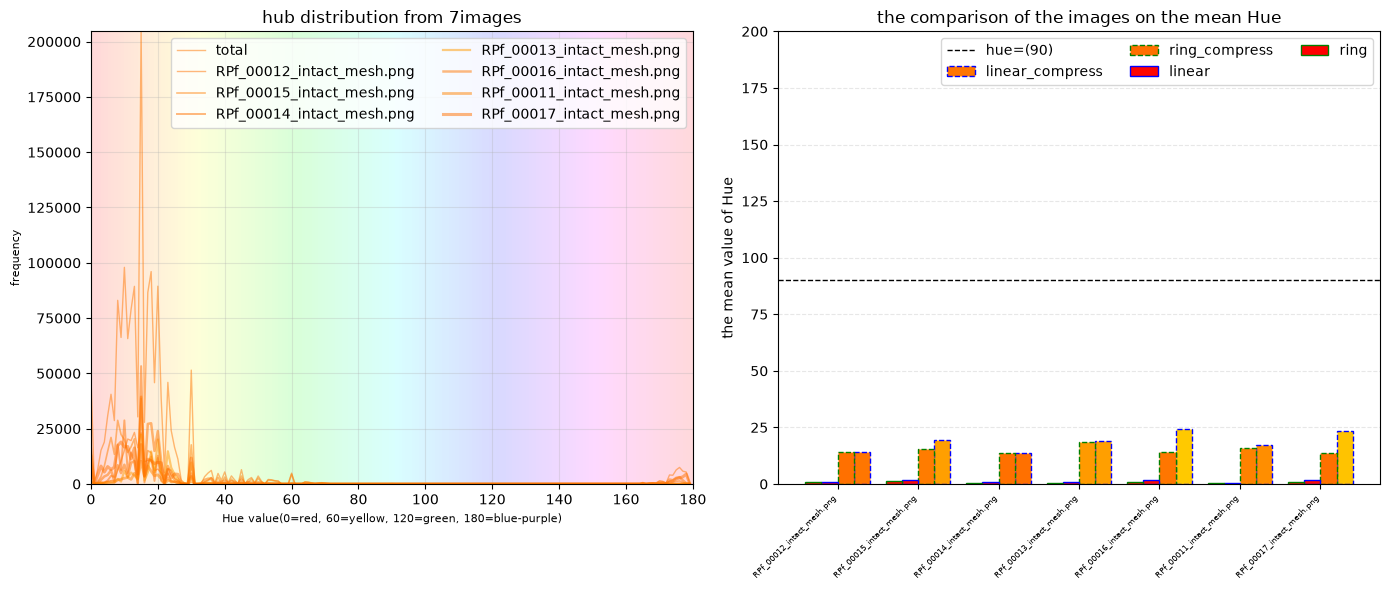

In [15]:
plot_hue_comparison(img_dir)